# Análisis por Componente (Repositorio)

Vista consolidada de **todos los hallazgos de todas las herramientas** para un repositorio específico.  
Útil para el análisis detallado de un componente antes de elaborar el informe final.

**Herramientas:** SBOM (Syft) · Secretos (Gitleaks) · Vulns. dependencias (Grype) · Vulns. código (CodeQL)  
**Objetivo:** Identificar el perfil completo de riesgo de un repositorio: tipos de componentes, categorías de secretos, severidades de vulnerabilidades y reglas CodeQL activadas.

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR = Path('../../data/results')

# ──────────────────────────────────────────────
# SELECCIÓN DEL REPOSITORIO A ANALIZAR
# Cambia este valor para analizar otro repositorio
# ──────────────────────────────────────────────
repos_disponibles = sorted({f.name.replace('-sbom.json', '')
                            for f in RESULTS_DIR.glob('*-sbom.json')})
print('Repositorios disponibles:')
for i, r in enumerate(repos_disponibles):
    print(f'  [{i}] {r}')

# Selecciona por índice o escribe el nombre directamente:
REPO = repos_disponibles[7] if repos_disponibles else ''
print(f'\n>>> Repositorio seleccionado: {REPO}')
print('    (modifica la variable REPO para analizar otro)')

Repositorios disponibles:
  [0] Requests
  [1] WordPress
  [2] WordPress-Coding-Standards
  [3] agent-skills
  [4] gutenberg
  [5] gutenberg-examples
  [6] mcp-adapter
  [7] two-factor
  [8] wordpress-develop
  [9] wordpress-playground

>>> Repositorio seleccionado: two-factor
    (modifica la variable REPO para analizar otro)


## 1. Carga de todos los resultados del repositorio

In [ ]:
def _load(suffix: str) -> dict | list:
    p = RESULTS_DIR / f'{REPO}{suffix}'
    if p.exists():
        return json.loads(p.read_text(encoding='utf-8'))
    print(f'  [!] No encontrado: {p.name}')
    return {}

sbom_data     = _load('-sbom.json')
gitleaks_data = _load('-gitleaks.json')
grype_data    = _load('-grype.json')
grype_raw     = _load('-grype-raw.json')
codeql_data   = _load('-codeql.json')

artifacts     = sbom_data.get('artifacts', [])
gitleaks_hls  = gitleaks_data.get('hallazgos', []) if isinstance(gitleaks_data, dict) else (gitleaks_data if isinstance(gitleaks_data, list) else [])
grype_vulns   = grype_data.get('vulnerabilities', [])
codeql_issues = codeql_data.get('issues', [])

print(f'\n=== Resumen de {REPO} ===')
print(f'  Componentes SBOM:           {len(artifacts)}')
print(f'  Secretos Gitleaks:          {len(gitleaks_hls)}')
print(f'  Vulns. dependencias Grype:  {len(grype_vulns)}')
print(f'  Issues CodeQL:              {len(codeql_issues)}')


=== Resumen de two-factor ===
  Componentes SBOM:           15
  Secretos Gitleaks:          18
  Vulns. dependencias Grype:  4
  Issues CodeQL:              0


## 2. Vista ejecutiva — Score de riesgo por categoría

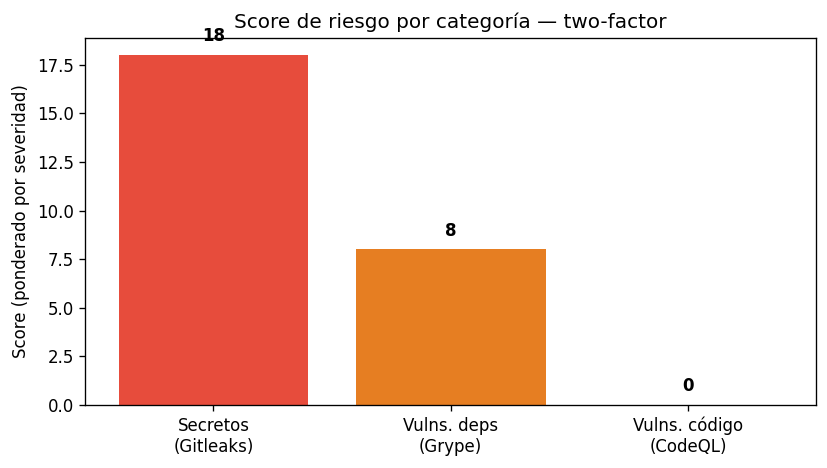

Score total: 26


In [ ]:
# Score simple: suma ponderada por severidad
PESOS_SEV = {'critical': 10, 'high': 5, 'medium': 2, 'low': 1}

score_secretos = len(gitleaks_hls)  # cada secreto vale 1 punto base

score_grype = sum(
    PESOS_SEV.get(v.get('vuln_severity', 'low').lower(), 1)
    for v in grype_vulns
)
score_codeql = sum(
    PESOS_SEV.get(i.get('severity', 'low').lower(), 1)
    for i in codeql_issues
)

categorias = ['Secretos\n(Gitleaks)', 'Vulns. deps\n(Grype)', 'Vulns. código\n(CodeQL)']
scores     = [score_secretos, score_grype, score_codeql]
colores    = ['#e74c3c', '#e67e22', '#3498db']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categorias, scores, color=colores)
for bar, v in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(v), ha='center', va='bottom', fontweight='bold')
ax.set_title(f'Score de riesgo por categoría — {REPO}')
ax.set_ylabel('Score (ponderado por severidad)')
plt.tight_layout()
plt.show()

print(f'Score total: {sum(scores)}')

## 3. Inventario de componentes (SBOM)

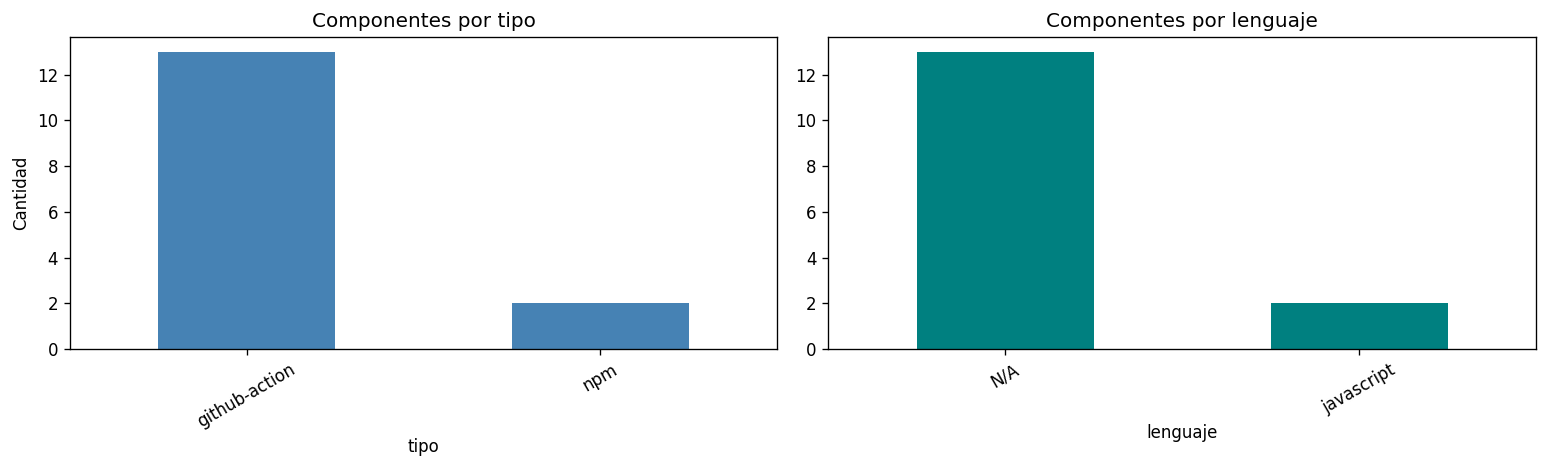

,nombre,version,tipo,lenguaje,licencias
0,10up/action-wordpress-plugin-asset-update,v2.2.0,github-action,N/A,sin licencia
1,10up/action-wordpress-plugin-deploy,v2.3.0,github-action,N/A,sin licencia
2,WordPress/props-bot-action,v1.0.0,github-action,N/A,sin licencia
3,actions/checkout,v6.0.0,github-action,N/A,sin licencia
4,actions/checkout,v6.0.0,github-action,N/A,sin licencia
5,actions/github-script,v7.0.1,github-action,N/A,sin licencia
6,actions/setup-node,v5.0.0,github-action,N/A,sin licencia
7,actions/setup-node,v5.0.0,github-action,N/A,sin licencia
8,codecov/codecov-action,671740ac38dd9b0130fbe1cec585b89eea48d3de,github-action,N/A,sin licencia
9,nick-fields/retry,v4.0.0,github-action,N/A,sin licencia


In [ ]:
if artifacts:
    df_sbom = pd.DataFrame([{
        'nombre':   a.get('name', ''),
        'version':  a.get('version', ''),
        'tipo':     a.get('type', ''),
        'lenguaje': a.get('language') or 'N/A',
        'licencias': ', '.join([
            (lic.get('value', lic) if isinstance(lic, dict) else lic)
            for lic in a.get('licenses', [])
        ]) or 'sin licencia',
    } for a in artifacts])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    df_sbom['tipo'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Componentes por tipo')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)

    df_sbom['lenguaje'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
    axes[1].set_title('Componentes por lenguaje')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    display(df_sbom)
else:
    print('Sin datos SBOM.')

## 4. Tipos de secretos detectados (Gitleaks)

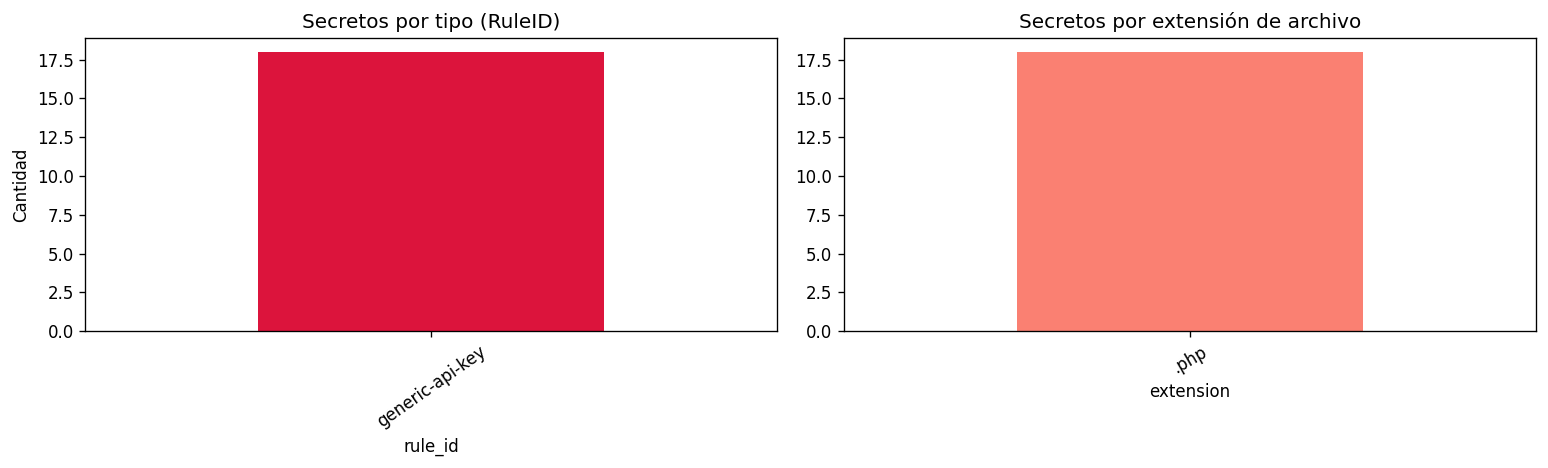

Entropía media: 5.26 | Max: 5.36
Autores distintos: 2


,rule_id,archivo,extension,entropia,autor,fecha
0,generic-api-key,class-two-factor-fido-u2f.php,.php,5.356043,Paul Schreiber,2020-06-16
1,generic-api-key,class-two-factor-fido-u2f.php,.php,5.356043,Paul Schreiber,2020-06-16
2,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
3,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
4,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
5,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
6,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
7,generic-api-key,class-two-factor-fido-u2f.php,.php,5.229825,Paul Schreiber,2020-06-16
8,generic-api-key,class.two-factor-fido-u2f.php,.php,5.229825,Daisuke Takahashi,2015-08-14
9,generic-api-key,class.two-factor-fido-u2f.php,.php,5.229825,Daisuke Takahashi,2015-08-14


In [ ]:
if gitleaks_hls:
    df_gl = pd.DataFrame([{
        'rule_id':    h.get('RuleID', 'desconocida'),
        'archivo':    Path(h.get('File', '')).name if h.get('File') else 'N/A',
        'extension':  Path(h.get('File', '')).suffix.lower() if h.get('File') else '',
        'entropia':   h.get('Entropy', 0.0),
        'autor':      h.get('Author', ''),
        'fecha':      h.get('Date', '')[:10] if h.get('Date') else '',
    } for h in gitleaks_hls])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    df_gl['rule_id'].value_counts().plot(kind='bar', ax=axes[0], color='crimson')
    axes[0].set_title('Secretos por tipo (RuleID)')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=35)

    df_gl['extension'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title('Secretos por extensión de archivo')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    print(f'Entropía media: {df_gl["entropia"].mean():.2f} | Max: {df_gl["entropia"].max():.2f}')
    print(f'Autores distintos: {df_gl["autor"].nunique()}')
    display(df_gl.head(20))
else:
    print('Sin hallazgos Gitleaks.')

## 5. Vulnerabilidades de dependencias (Grype)

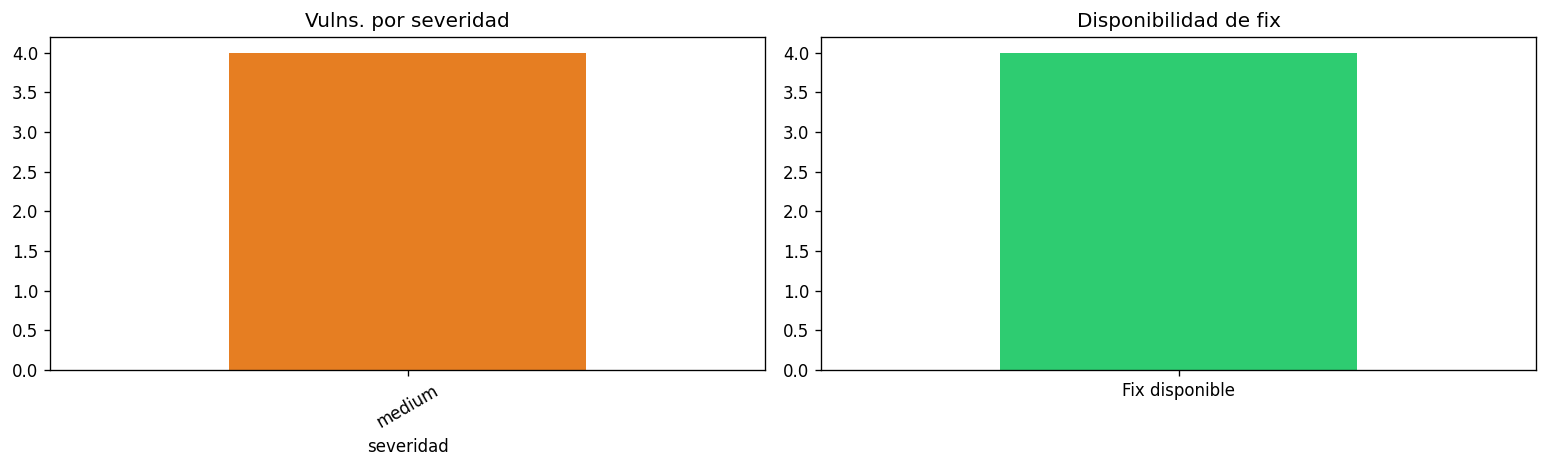

Distribución por severidad:


,cantidad
severidad,
medium,4



Top vulnerabilidades críticas/altas:


,paquete,version,vuln_id,severidad,fix,cvss,tiene_fix


In [ ]:
SEVERIDAD_ORDEN = ['critical', 'high', 'medium', 'low', 'negligible', 'unknown']
COLORES_SEV     = {'critical': '#c0392b', 'high': '#e74c3c', 'medium': '#e67e22',
                   'low': '#f1c40f', 'negligible': '#95a5a6', 'unknown': '#bdc3c7'}

if grype_vulns:
    df_gr = pd.DataFrame([{
        'paquete':    v.get('package_name', ''),
        'version':    v.get('current_version', ''),
        'vuln_id':    v.get('vuln_id', ''),
        'severidad':  v.get('vuln_severity', 'unknown').lower(),
        'fix':        v.get('fix_version', 'N/A'),
        'cvss':       float(v.get('cvss_score', 0) or 0),
        'tiene_fix':  str(v.get('fix_version', 'N/A')).strip().upper() not in ('N/A', '', 'NONE'),
    } for v in grype_vulns])

    sev_counts = df_gr['severidad'].value_counts()
    sev_ord = sev_counts.reindex([s for s in SEVERIDAD_ORDEN if s in sev_counts.index])
    colores = [COLORES_SEV.get(s, 'gray') for s in sev_ord.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sev_ord.plot(kind='bar', ax=axes[0], color=colores)
    axes[0].set_title('Vulns. por severidad')
    axes[0].tick_params(axis='x', rotation=30)

    fix_counts = df_gr['tiene_fix'].value_counts()
    fix_counts.index = ['Fix disponible' if v else 'Sin fix' for v in fix_counts.index]
    fix_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Disponibilidad de fix')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    print('Distribución por severidad:')
    display(sev_ord.to_frame('cantidad'))
    print('\nTop vulnerabilidades críticas/altas:')
    display(df_gr[df_gr['severidad'].isin(['critical','high'])]
              .sort_values('cvss', ascending=False)
              .head(15)
              .reset_index(drop=True))
else:
    print('Sin vulnerabilidades Grype.')

## 6. Vulnerabilidades de código (CodeQL)

In [ ]:
def _cq_archivo(issue):
    """El archivo puede venir como campo de nivel superior (`file`) o anidado en `location`."""
    loc = issue.get('location', {})
    if not isinstance(loc, dict):
        loc = {}
    return issue.get('file') or loc.get('uri') or loc.get('file') or ''

if codeql_issues:
    df_cq = pd.DataFrame([{
        'rule_id':   issue.get('rule_id', issue.get('ruleId', 'desconocida')),
        'severidad': issue.get('severity', issue.get('level', 'desconocida')).lower(),
        'mensaje':   issue.get('message', ''),
        'archivo':   _cq_archivo(issue),
    } for issue in codeql_issues])

    sev_cq = df_cq['severidad'].value_counts()
    sev_cq_ord = sev_cq.reindex([s for s in ['critical','high','medium','low','warning','note'] if s in sev_cq.index])
    colores_cq = [COLORES_SEV.get(s, '#95a5a6') for s in sev_cq_ord.index]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sev_cq_ord.plot(kind='bar', ax=axes[0], color=colores_cq)
    axes[0].set_title('Issues CodeQL por severidad')
    axes[0].tick_params(axis='x', rotation=30)

    df_cq['rule_id'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='mediumpurple')
    axes[1].set_title('Issues por tipo de regla (top 10)')
    axes[1].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()

    display(df_cq.head(20))
else:
    print('Sin issues CodeQL (puede que no esté instalado o que el lenguaje no sea compatible).')

## 7. Perfil completo de riesgo (resumen visual)

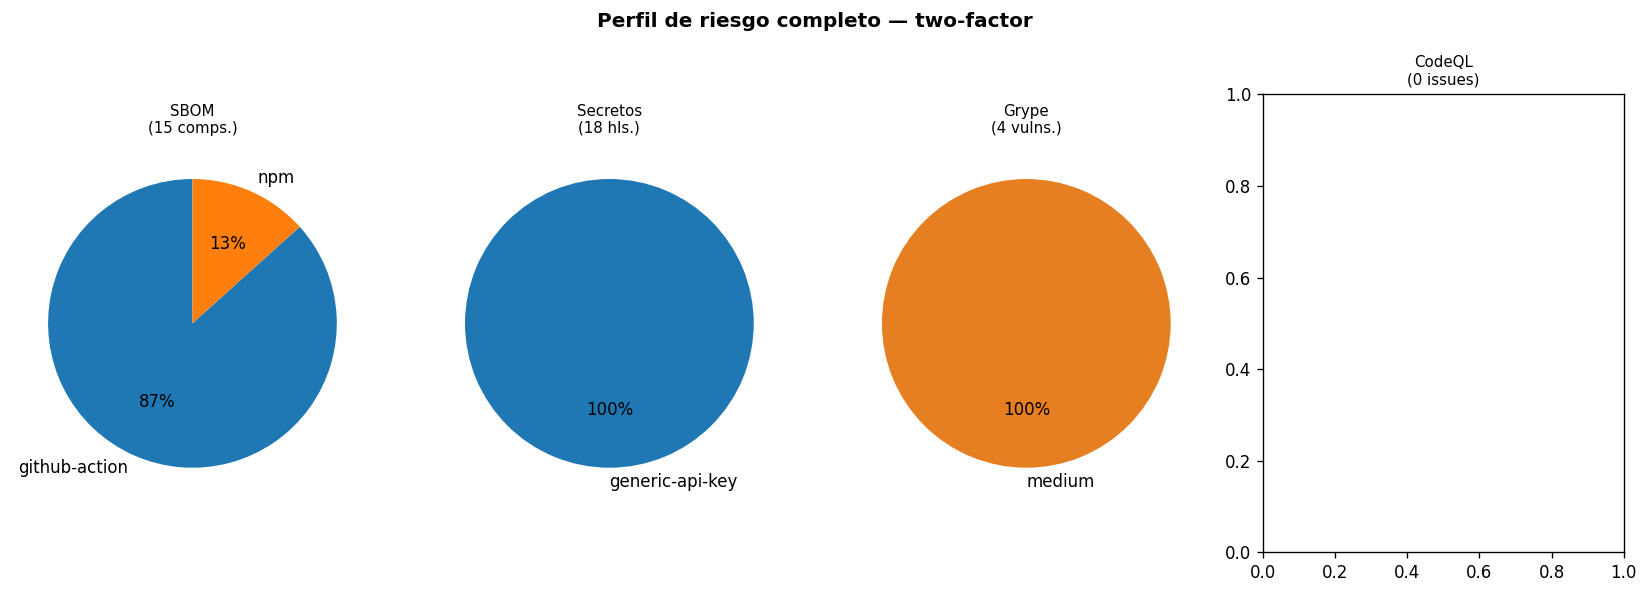

In [ ]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig)

# Panel 1: componentes por tipo
ax1 = fig.add_subplot(gs[0])
if artifacts:
    tipos = pd.Series([a.get('type','?') for a in artifacts]).value_counts()
    ax1.pie(tipos, labels=tipos.index, autopct='%1.0f%%', startangle=90)
ax1.set_title(f'SBOM\n({len(artifacts)} comps.)', fontsize=9)

# Panel 2: secretos por tipo
ax2 = fig.add_subplot(gs[1])
if gitleaks_hls:
    rules = pd.Series([h.get('RuleID','?') for h in gitleaks_hls]).value_counts().head(6)
    ax2.pie(rules, labels=rules.index, autopct='%1.0f%%', startangle=90)
ax2.set_title(f'Secretos\n({len(gitleaks_hls)} hls.)', fontsize=9)

# Panel 3: vulns grype por severidad
ax3 = fig.add_subplot(gs[2])
if grype_vulns:
    sev_g = pd.Series([v.get('vuln_severity','?').lower() for v in grype_vulns]).value_counts()
    sev_g = sev_g.reindex([s for s in SEVERIDAD_ORDEN if s in sev_g.index])
    ax3.pie(sev_g, labels=sev_g.index,
            colors=[COLORES_SEV.get(s,'gray') for s in sev_g.index],
            autopct='%1.0f%%', startangle=90)
ax3.set_title(f'Grype\n({len(grype_vulns)} vulns.)', fontsize=9)

# Panel 4: codeql por severidad
ax4 = fig.add_subplot(gs[3])
if codeql_issues:
    sev_c = pd.Series([i.get('severity','?').lower() for i in codeql_issues]).value_counts()
    ax4.pie(sev_c, labels=sev_c.index,
            colors=[COLORES_SEV.get(s,'#95a5a6') for s in sev_c.index],
            autopct='%1.0f%%', startangle=90)
ax4.set_title(f'CodeQL\n({len(codeql_issues)} issues)', fontsize=9)

plt.suptitle(f'Perfil de riesgo completo — {REPO}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()